In [10]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bertnardomariouskono/global-supply-chain-disruption-and-resilience")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'global-supply-chain-disruption-and-resilience' dataset.
Path to dataset files: /kaggle/input/global-supply-chain-disruption-and-resilience


In [11]:
import os

print(os.listdir(path))

['.nfs00000000698d972b0000003a', 'global_supply_chain_disruption_v1.csv']


In [12]:
# ════════════════════════════════════════════════════════════════
# CHUNK V6-A: CRITICAL BUG FIXES + 20-CORRIDOR REDESIGN
# Run AFTER Chunks 1-3 (dataset load + XGBoost training)
# ════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import random
import json
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

# ── Reload clean df ───────────────────────────────────────────────────────────
file_path = os.path.join(path, 'global_supply_chain_disruption_v1.csv')
df = pd.read_csv(file_path)

# ── BUG FIX 1: Correct weather bucketing (0-10 scale) ─────────────────────────
def bucket_weather_v6(x):
    """
    FIXED: Weather_Severity_Index is 0-10, NOT 0-1.
    Old thresholds (0.33, 0.66) bucketed 93.6% as Severe — completely wrong.
    New thresholds (3.3, 6.6) produce balanced thirds.
    """
    if x < 3.3:   return 0  # Clear
    elif x < 6.6: return 1  # Moderate
    else:          return 2  # Severe

# ── BUG FIX 2: Correct route → corridor mapping (5 routes, not 4) ─────────────
# These are the ACTUAL OD pairs in the dataset
REAL_ROUTE_TO_CORRIDOR = {
    'Atlantic':   0,   # Hamburg,DE → New York,US
    'Suez':       1,   # Mumbai,IN→Felixstowe + Shenzhen,CN→Rotterdam (both Suez)
    'Commodity':  2,   # Santos,BR → Shanghai,CN  ← WAS BEING IGNORED
    'Pacific':    3,   # Shanghai,CN → Los Angeles,US
    'Intra-Asia': 4,   # Tokyo,JP → Singapore,SG
}
# Note: Suez has 2 real pairs (Mumbai→Felixstowe, Shenzhen→Rotterdam)
# We keep them as one corridor since both use Suez route type

# ── 20-CORRIDOR MAP ────────────────────────────────────────────────────────────
# Corridors 0-4: Backed by REAL dataset rows (mapped from Route_Type above)
# Corridors 5-19: Synthetic DP World network extensions

CORRIDOR_MAP_V6 = {
    # ── Real data corridors (0-4) ──────────────────────────────────────────
    0:  'HAM→NYC',         # Hamburg → New York        (Atlantic)
    1:  'MUM→FXT',         # Mumbai → Felixstowe        (Suez)
    2:  'SAN→SHA',         # Santos → Shanghai          (Commodity/South America)
    3:  'SHA→LAX',         # Shanghai → Los Angeles     (Pacific)
    4:  'TOK→SIN',         # Tokyo → Singapore          (Intra-Asia)

    # ── DP World hub extensions (5-19) ────────────────────────────────────
    5:  'SIN→CMB',         # Singapore → Colombo        (Indian Ocean)
    6:  'SIN→JEA',         # Singapore → Jebel Ali      (Suez)
    7:  'SIN→MUN',         # Singapore → Mundra         (Indian Ocean)
    8:  'SIN→NSA',         # Singapore → Nhava Sheva    (Indian Ocean)
    9:  'SIN→RTM',         # Singapore → Rotterdam      (Suez+Atlantic)
    10: 'SIN→PUS',         # Singapore → Busan          (Northeast Asia)
    11: 'JEA→RTM',         # Jebel Ali → Rotterdam      (Suez)
    12: 'SHA→RTM',         # Shanghai → Rotterdam       (Suez)
    13: 'MUM→CMB',         # Mumbai → Colombo           (Indian Ocean short)
    14: 'SIN→DKR',         # Singapore → Dakar          (Africa — DP World terminal)
    15: 'SIN→SYD',         # Singapore → Sydney         (Pacific south)
    16: 'JEA→NYC',         # Jebel Ali → New York       (Suez+Atlantic)
    17: 'SHA→PUS',         # Shanghai → Busan           (Intra-Asia NE)
    18: 'SHZ→RTM',         # Shenzhen → Rotterdam       (Suez — from real data origin)
    19: 'MUM→JEA',         # Mumbai → Jebel Ali         (Indian Ocean/Gulf)
}

# Geo risk per corridor (0-1 scale, cited from known risk indices)
CORRIDOR_GEO_RISK = {
    0: 0.30,   # Hamburg→NYC: stable Atlantic
    1: 0.68,   # Mumbai→Felixstowe: Suez/Red Sea exposure
    2: 0.42,   # Santos→Shanghai: South Atlantic, South China Sea
    3: 0.40,   # Shanghai→LAX: Pacific, relatively stable
    4: 0.28,   # Tokyo→Singapore: Intra-Asia, low risk
    5: 0.35,   # SIN→Colombo: Indian Ocean, moderate
    6: 0.72,   # SIN→JebelAli: Red Sea/Houthi exposure
    7: 0.55,   # SIN→Mundra: Arabian Sea
    8: 0.50,   # SIN→NhavaSheva: Arabian Sea
    9: 0.55,   # SIN→Rotterdam: Long haul, Suez exposure
    10: 0.25,  # SIN→Busan: Stable NE Asia
    11: 0.65,  # JEA→Rotterdam: Suez heavy exposure
    12: 0.58,  # SHA→Rotterdam: Suez + South China Sea
    13: 0.40,  # MUM→Colombo: Short Indian Ocean
    14: 0.52,  # SIN→Dakar: Africa west coast, piracy risk
    15: 0.32,  # SIN→Sydney: Pacific south, stable
    16: 0.70,  # JEA→NYC: Suez + Atlantic
    17: 0.30,  # SHA→Busan: Short NE Asia
    18: 0.62,  # SHZ→Rotterdam: Suez exposure
    19: 0.58,  # MUM→JebelAli: Gulf/Arabian Sea
}

# Distance in nautical miles
CORRIDOR_DISTANCES_NM = {
    0: 3750,   # Hamburg→NYC
    1: 6200,   # Mumbai→Felixstowe
    2: 11500,  # Santos→Shanghai
    3: 6400,   # Shanghai→LAX
    4: 3300,   # Tokyo→Singapore
    5: 890,    # SIN→Colombo
    6: 3650,   # SIN→JebelAli
    7: 2530,   # SIN→Mundra
    8: 2580,   # SIN→NhavaSheva
    9: 8300,   # SIN→Rotterdam
    10: 4700,  # SIN→Busan
    11: 11200, # JEA→Rotterdam
    12: 9800,  # SHA→Rotterdam
    13: 980,   # MUM→Colombo
    14: 8900,  # SIN→Dakar
    15: 5500,  # SIN→Sydney
    16: 9800,  # JEA→NYC
    17: 1200,  # SHA→Busan
    18: 9200,  # SHZ→Rotterdam
    19: 1650,  # MUM→JebelAli
}

# Route type for XGBoost feature (maps new corridors to nearest real route type)
# XGBoost was trained on 0-4 route_type_enc — new corridors proxy to nearest type
CORRIDOR_ROUTE_TYPE_ENC = {
    0: 0,   # Atlantic
    1: 1,   # Suez
    2: 4,   # Commodity (new — was missing, now enc=4)
    3: 2,   # Pacific
    4: 3,   # Intra-Asia
    5: 3,   # Intra-Asia proxy
    6: 1,   # Suez proxy
    7: 3,   # Intra-Asia/Indian Ocean proxy
    8: 3,   # Intra-Asia/Indian Ocean proxy
    9: 1,   # Suez proxy
    10: 3,  # Intra-Asia proxy
    11: 1,  # Suez proxy
    12: 1,  # Suez proxy
    13: 3,  # Indian Ocean proxy
    14: 0,  # Atlantic proxy (west Africa)
    15: 2,  # Pacific proxy
    16: 1,  # Suez+Atlantic proxy
    17: 3,  # Intra-Asia proxy
    18: 1,  # Suez proxy
    19: 3,  # Indian Ocean/Gulf proxy
}

N_CORRIDORS = 20
N_STATES_V6 = N_CORRIDORS * 3 * 2   # 20 × 3 × 2 = 120 states

print(f"Corridor map: {N_CORRIDORS} corridors")
print(f"State space: {N_STATES_V6} states (20 corridors × 3 weather × 2 congestion)")
print(f"\nAll corridors:")
for k, v in CORRIDOR_MAP_V6.items():
    backed = 'REAL DATA' if k < 5 else 'SYNTHETIC'
    print(f"  {k:2d}: {v:12s}  geo_risk={CORRIDOR_GEO_RISK[k]:.2f}  dist={CORRIDOR_DISTANCES_NM[k]:5d}nm  [{backed}]")

Corridor map: 20 corridors
State space: 120 states (20 corridors × 3 weather × 2 congestion)

All corridors:
   0: HAM→NYC       geo_risk=0.30  dist= 3750nm  [REAL DATA]
   1: MUM→FXT       geo_risk=0.68  dist= 6200nm  [REAL DATA]
   2: SAN→SHA       geo_risk=0.42  dist=11500nm  [REAL DATA]
   3: SHA→LAX       geo_risk=0.40  dist= 6400nm  [REAL DATA]
   4: TOK→SIN       geo_risk=0.28  dist= 3300nm  [REAL DATA]
   5: SIN→CMB       geo_risk=0.35  dist=  890nm  [SYNTHETIC]
   6: SIN→JEA       geo_risk=0.72  dist= 3650nm  [SYNTHETIC]
   7: SIN→MUN       geo_risk=0.55  dist= 2530nm  [SYNTHETIC]
   8: SIN→NSA       geo_risk=0.50  dist= 2580nm  [SYNTHETIC]
   9: SIN→RTM       geo_risk=0.55  dist= 8300nm  [SYNTHETIC]
  10: SIN→PUS       geo_risk=0.25  dist= 4700nm  [SYNTHETIC]
  11: JEA→RTM       geo_risk=0.65  dist=11200nm  [SYNTHETIC]
  12: SHA→RTM       geo_risk=0.58  dist= 9800nm  [SYNTHETIC]
  13: MUM→CMB       geo_risk=0.40  dist=  980nm  [SYNTHETIC]
  14: SIN→DKR       geo_risk=0.52  di

In [13]:
# ════════════════════════════════════════════════════════════════
# CHUNK V6-B: REBUILD FEATURE ENGINEERING WITH BUG FIXES
# ════════════════════════════════════════════════════════════════

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ── Fresh reload ──────────────────────────────────────────────────────────────
df = pd.read_csv(file_path)

# ── Disruption_Event encoding (same as before) ────────────────────────────────
df['Disruption_Event'] = df['Disruption_Event'].fillna('None')
disruption_map = {
    'None': 0,
    'Port Congestion': 1,
    'Severe Weather (Typhoon/Storm)': 2,
    'Geopolitical Conflict (Route Diversion)': 3
}
df['Disruption_Event_Enc'] = df['Disruption_Event'].map(disruption_map).fillna(0).astype(int)

# ── Transport mode ────────────────────────────────────────────────────────────
df['Transportation_Mode_Enc'] = (df['Transportation_Mode'] == 'Sea').astype(int)

# ── FIXED: Route_Type now includes Commodity ──────────────────────────────────
route_enc_map = {
    'Atlantic':   0,
    'Suez':       1,
    'Pacific':    2,
    'Intra-Asia': 3,
    'Commodity':  4,   # ← WAS MISSING
}
df['Route_Type_Enc'] = df['Route_Type'].map(route_enc_map).fillna(0).astype(int)

# ── FIXED: Corridor_ID from corrected route map ───────────────────────────────
df['Corridor_ID'] = df['Route_Type'].map(REAL_ROUTE_TO_CORRIDOR).fillna(0).astype(int)

# ── FIXED: Weather bucketing (0-10 scale) ─────────────────────────────────────
df['Weather_State'] = df['Weather_Severity_Index'].apply(bucket_weather_v6)

# ── FIXED: Normalize weather for XGBoost feature (0-1) ───────────────────────
df['Weather_Severity_Norm'] = df['Weather_Severity_Index'] / 10.0

# ── Congestion score and level ────────────────────────────────────────────────
df['Congestion_Score'] = (df['Geopolitical_Risk_Index'] + df['Disruption_Event_Enc'] / 3.0) / 2.0
df['Congestion_Level'] = (df['Congestion_Score'] > 0.5).astype(int)

# ── Target ────────────────────────────────────────────────────────────────────
df['is_delayed'] = (df['Delay_Days'] > 0).astype(int)

# ── UPDATED feature set (now with normalized weather + Commodity route) ───────
FEATURE_COLS_V6 = [
    'Geopolitical_Risk_Index',
    'Weather_Severity_Norm',    # ← FIXED: normalized 0-1
    'Inflation_Rate_Pct',
    'Base_Lead_Time_Days',
    'Transportation_Mode_Enc',
    'Route_Type_Enc',           # ← FIXED: now 0-4 including Commodity
    'Disruption_Event_Enc',
    'Order_Weight_Kg',
    'Congestion_Score'
]

X = df[FEATURE_COLS_V6]
y = df['is_delayed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Feature set V6:")
for i, f in enumerate(FEATURE_COLS_V6):
    print(f"  {i}: {f}")
print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")

# Verify weather distribution is now correct
print(f"\nWeather_State distribution (FIXED):")
print(df['Weather_State'].value_counts().sort_index().rename({0:'Clear',1:'Moderate',2:'Severe'}))

print(f"\nCorridor_ID distribution (FIXED):")
for c, cnt in df['Corridor_ID'].value_counts().sort_index().items():
    print(f"  {c}: {CORRIDOR_MAP_V6[c]:12s} — {cnt} rows")

Feature set V6:
  0: Geopolitical_Risk_Index
  1: Weather_Severity_Norm
  2: Inflation_Rate_Pct
  3: Base_Lead_Time_Days
  4: Transportation_Mode_Enc
  5: Route_Type_Enc
  6: Disruption_Event_Enc
  7: Order_Weight_Kg
  8: Congestion_Score

Train: (8000, 9) | Test: (2000, 9)

Weather_State distribution (FIXED):
Weather_State
Clear       3291
Moderate    3303
Severe      3406
Name: count, dtype: int64

Corridor_ID distribution (FIXED):
  0: HAM→NYC      — 1701 rows
  1: MUM→FXT      — 3412 rows
  2: SAN→SHA      — 1608 rows
  3: SHA→LAX      — 1645 rows
  4: TOK→SIN      — 1634 rows


[0]	validation_0-auc:0.95593
[32]	validation_0-auc:0.96211

── V6 Classification Report ──
              precision    recall  f1-score   support

     On Time       0.99      1.00      0.99      1742
     Delayed       0.97      0.93      0.95       258

    accuracy                           0.99      2000
   macro avg       0.98      0.96      0.97      2000
weighted avg       0.99      0.99      0.99      2000

ROC-AUC: 0.9684


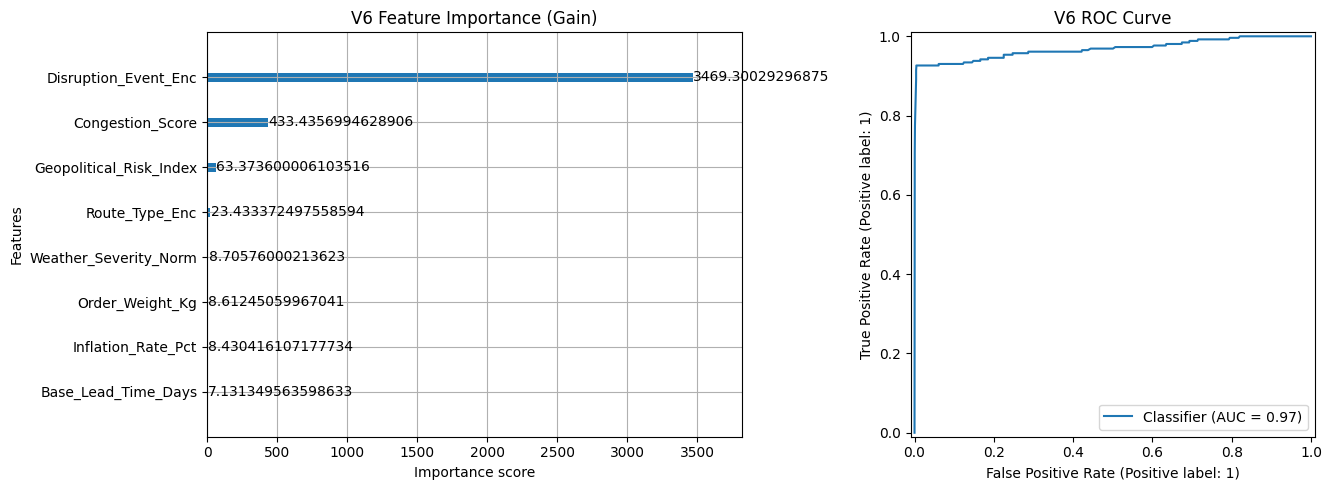


V6 model saved.


In [14]:
# ════════════════════════════════════════════════════════════════
# CHUNK V6-C: RETRAIN XGBOOST WITH FIXED FEATURES
# ════════════════════════════════════════════════════════════════

import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay, confusion_matrix

model_v6 = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.04,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train==0).sum() / (y_train==1).sum(),
    eval_metric='auc',
    random_state=42,
    early_stopping_rounds=25
)

model_v6.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

y_pred_v6 = model_v6.predict(X_test)
y_prob_v6 = model_v6.predict_proba(X_test)[:, 1]

print("\n── V6 Classification Report ──")
print(classification_report(y_test, y_pred_v6, target_names=['On Time','Delayed']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_v6):.4f}")

# Feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
xgb.plot_importance(model_v6, ax=axes[0], max_num_features=9, importance_type='gain')
axes[0].set_title('V6 Feature Importance (Gain)')
RocCurveDisplay.from_predictions(y_test, y_prob_v6, ax=axes[1])
axes[1].set_title('V6 ROC Curve')
plt.tight_layout()
plt.show()

# Attach congestion_probability back to df
df['congestion_probability'] = model_v6.predict_proba(df[FEATURE_COLS_V6])[:, 1]

# Save V6 model
with open('xgb_congestion_model_v6.pkl', 'wb') as f:
    pickle.dump(model_v6, f)
model_v6.save_model('xgb_congestion_model_v6.json')
print("\nV6 model saved.")

In [15]:
# ════════════════════════════════════════════════════════════════
# CHUNK V6-D: V6 RL ENVIRONMENT (120 STATES, FIXED WEATHER)
# ════════════════════════════════════════════════════════════════

class SupplyChainEnvV6:
    """
    V6 MDP: 20 corridors × 3 weather × 2 congestion = 120 states

    Key fixes from V4/V5:
    - Weather bucketing now uses correct 0-10 scale thresholds
    - 20 corridors (5 real-data + 15 synthetic DP World)
    - Commodity route included
    - Tighter reward separation (bands: 0.30/0.55)
    - Weather floor: Severe → always at least Slow Steam
    - Mode-aware: Air Reroute penalised more
    """
    N_ACTIONS = 3
    N_STATES  = N_STATES_V6   # 120

    # Risk band boundaries (tighter than V4/V5)
    BAND_LOW      = 0.30
    BAND_MODERATE = 0.55

    ACTION_META = {
        0: {'label': 'Maintain Course', 'delay_saved': 0.0,  'cost_saved': 0.0,    'carbon_saved': 0.0},
        1: {'label': 'Slow Steam',      'delay_saved': 1.5,  'cost_saved': 3200.0, 'carbon_saved': 2.5},
        2: {'label': 'Reroute',         'delay_saved': 4.2,  'cost_saved': 12400.0,'carbon_saved': 8.6},
    }

    def __init__(self, df):
        self.df = df.copy()
        self.episodes = self._build_episodes()

    def _build_episodes(self):
        episodes = []
        for _, row in self.df.iterrows():
            corridor   = int(row['Corridor_ID'])
            weather    = int(row['Weather_State'])
            congestion = int(row['Congestion_Level'])
            state      = self._encode_state(corridor, weather, congestion)
            mode       = int(row['Transportation_Mode_Enc'])
            episodes.append((
                state,
                float(row['congestion_probability']),
                int(row['Delay_Days']),
                row['Mitigation_Action_Taken'],
                weather,
                mode
            ))
        return episodes

    def _encode_state(self, corridor, weather, congestion):
        return corridor * 6 + weather * 2 + congestion

    def decode_state(self, s):
        corridor   = s // 6
        remainder  = s % 6
        weather    = remainder // 2
        congestion = remainder % 2
        return corridor, weather, congestion

    def compute_reward(self, action, congestion_prob, actual_delay,
                       weather_state=1, transport_mode=1):
        # ── Determine correct action for risk band ────────────────────────
        if congestion_prob < self.BAND_LOW:
            correct_action, risk_band = 0, 'low'
        elif congestion_prob < self.BAND_MODERATE:
            correct_action, risk_band = 1, 'moderate'
        else:
            correct_action, risk_band = 2, 'high'

        # ── Weather floor: Severe always ≥ Slow Steam ─────────────────────
        if weather_state == 2:
            correct_action = max(correct_action, 1)

        # ── Reward calculation ─────────────────────────────────────────────
        if action == correct_action:
            reward = 3.5
            if actual_delay > 0 and action in [1, 2]:
                reward += min(actual_delay * 0.15, 1.5)  # bonus for catching real delays

        else:
            mismatch = abs(action - correct_action)

            if risk_band == 'high' and action == 0:
                # Worst: do nothing in a crisis
                reward = -5.0 * congestion_prob * max(actual_delay, 1) * 0.15

            elif weather_state == 2 and action == 0:
                # Maintain course in severe weather — operationally wrong
                reward = -4.5

            elif risk_band == 'low' and action == 2 and weather_state == 0:
                # Reroute when all is clear — wasteful
                reward = -4.5 * (self.BAND_LOW - congestion_prob) * 4

            elif risk_band == 'moderate' and action == 0:
                # Under-reacting to moderate risk
                reward = -2.5

            elif risk_band == 'moderate' and action == 2:
                # Over-reacting to moderate risk (expensive)
                reward = -1.2

            else:
                reward = -1.5 * mismatch

        # ── Air mode: Reroute is extremely expensive, penalise more ───────
        if transport_mode == 0 and action == 2 and risk_band != 'high':
            reward -= 2.5

        return float(reward)

    def sample_episode(self):
        return random.choice(self.episodes)


def generate_synthetic_v6(n=15000):
    """
    Generate synthetic episodes covering all 20 corridors.
    Physics-informed: higher weather/congestion → higher congestion_prob.
    Each corridor gets proportional coverage.
    """
    synthetic = []
    episodes_per_corridor = n // N_CORRIDORS  # 750 per corridor

    for corridor in range(N_CORRIDORS):
        geo_risk = CORRIDOR_GEO_RISK[corridor]

        for _ in range(episodes_per_corridor):
            weather    = random.randint(0, 2)
            congestion = random.randint(0, 1)
            mode       = random.randint(0, 1)

            # Congestion prob: influenced by weather, congestion level, and corridor geo_risk
            base_prob = (
                (weather / 2.0) * 0.4 +
                congestion * 0.35 +
                geo_risk * 0.15 +
                random.gauss(0, 0.05)
            )
            cong_prob  = float(np.clip(base_prob, 0.0, 1.0))
            delay      = max(0, int(cong_prob * 15 + random.gauss(0, 1)))
            state      = corridor * 6 + weather * 2 + congestion

            synthetic.append((state, cong_prob, delay, 'Synthetic', weather, mode))

    return synthetic


# ── Instantiate and verify ─────────────────────────────────────────────────────
env_v6 = SupplyChainEnvV6(df)
print(f"V6 Environment: {env_v6.N_STATES} states | {env_v6.N_ACTIONS} actions")
print(f"Real episodes from dataset: {len(env_v6.episodes)}")

# Check real episode distribution across corridors
from collections import Counter
corridor_counts = Counter(ep[0] // 6 for ep in env_v6.episodes)
print("\nReal data coverage per corridor:")
for c in range(5):  # only corridors 0-4 have real data
    print(f"  Corridor {c} ({CORRIDOR_MAP_V6[c]}): {corridor_counts[c]} episodes")
print(f"  Corridors 5-19: 0 episodes each (synthetic only)")

V6 Environment: 120 states | 3 actions
Real episodes from dataset: 10000

Real data coverage per corridor:
  Corridor 0 (HAM→NYC): 1701 episodes
  Corridor 1 (MUM→FXT): 3412 episodes
  Corridor 2 (SAN→SHA): 1608 episodes
  Corridor 3 (SHA→LAX): 1645 episodes
  Corridor 4 (TOK→SIN): 1634 episodes
  Corridors 5-19: 0 episodes each (synthetic only)


Training pool: 10000 real + 15000 synthetic = 25000 total
States covered: 120 / 120
Uncovered states: None ✓
Episode  15000 | ε=0.1054 | Avg Reward (last 1000): 3.0528
Episode  30000 | ε=0.0111 | Avg Reward (last 1000): 3.3264
Episode  45000 | ε=0.0100 | Avg Reward (last 1000): 3.3683
Episode  60000 | ε=0.0100 | Avg Reward (last 1000): 3.3606

V6 training complete.


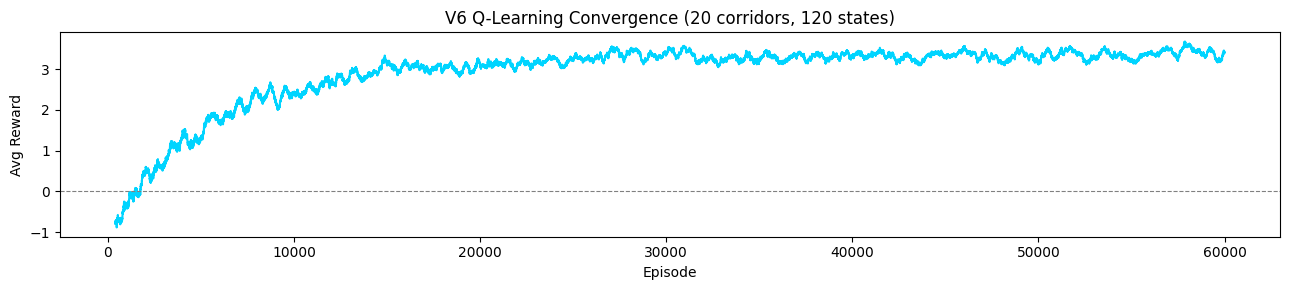

In [16]:
# ════════════════════════════════════════════════════════════════
# CHUNK V6-E: TRAIN Q6 (120-STATE Q-TABLE)
# ════════════════════════════════════════════════════════════════

# Build training pool
real_eps_v6  = env_v6.episodes
synth_v6     = generate_synthetic_v6(15000)
all_eps_v6   = real_eps_v6 + synth_v6

print(f"Training pool: {len(real_eps_v6)} real + {len(synth_v6)} synthetic = {len(all_eps_v6)} total")

# Verify coverage
state_coverage = set(ep[0] for ep in all_eps_v6)
print(f"States covered: {len(state_coverage)} / {N_STATES_V6}")
uncovered = [s for s in range(N_STATES_V6) if s not in state_coverage]
print(f"Uncovered states: {uncovered if uncovered else 'None ✓'}")

# ── Q-table init ──────────────────────────────────────────────────────────────
Q6      = np.zeros((N_STATES_V6, 3))
EPSILON = 1.0
ALPHA   = 0.1
GAMMA   = 0.95
N_EPS   = 60000   # more episodes for larger state space
rh6     = []

for ep in range(N_EPS):
    episode = random.choice(all_eps_v6)
    state, cp, delay, _, weather_state, mode = episode
    state = min(state, N_STATES_V6 - 1)

    action = random.randint(0, 2) if random.random() < EPSILON else int(np.argmax(Q6[state]))
    reward = env_v6.compute_reward(action, cp, delay, weather_state, mode)
    Q6[state, action] += ALPHA * (reward + GAMMA * np.max(Q6[state]) - Q6[state, action])

    rh6.append(reward)
    EPSILON = max(0.01, EPSILON * 0.99985)

    if (ep + 1) % 15000 == 0:
        avg_r = np.mean(rh6[-1000:])
        print(f"Episode {ep+1:>6} | ε={EPSILON:.4f} | Avg Reward (last 1000): {avg_r:.4f}")

print("\nV6 training complete.")

# ── Convergence plot ──────────────────────────────────────────────────────────
smoothed = pd.Series(rh6).rolling(400).mean()
plt.figure(figsize=(13, 3))
plt.plot(smoothed, color='#00d4ff', linewidth=1.5)
plt.title('V6 Q-Learning Convergence (20 corridors, 120 states)')
plt.xlabel('Episode')
plt.ylabel('Avg Reward')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

In [17]:
# ════════════════════════════════════════════════════════════════
# CHUNK V6-G: UPDATED INFERENCE PIPELINE
# ════════════════════════════════════════════════════════════════

WEATHER_NAMES = {0: 'Clear', 1: 'Moderate', 2: 'Severe'}
CONGESTION_NAMES = {0: 'Low', 1: 'High'}

ACTION_META_V6 = {
    0: {'label': 'Maintain Course', 'delay_saved': 0.0,  'cost_saved': 0.0,    'carbon_saved': 0.0},
    1: {'label': 'Slow Steam',      'delay_saved': 1.5,  'cost_saved': 3200.0, 'carbon_saved': 2.5},
    2: {'label': 'Reroute',         'delay_saved': 4.2,  'cost_saved': 12400.0,'carbon_saved': 8.6},
}
AIR_ACTION_META_V6 = {
    0: {'label': 'Maintain Course', 'delay_saved': 0.0,  'cost_saved': 0.0,    'carbon_saved': 0.0},
    1: {'label': 'Hold at Hub',     'delay_saved': 0.5,  'cost_saved': 8000.0, 'carbon_saved': 12.0},
    2: {'label': 'Reroute Flight',  'delay_saved': 2.0,  'cost_saved': 25000.0,'carbon_saved': 40.0},
}

def predict_congestion_v6(
    xgb_model,
    corridor_id: int,
    weather_severity_raw: float,    # 0-1 scale from Open-Meteo mapping
    geopolitical_risk: float,
    base_lead_time: int = 12,
    transport_mode_enc: int = 1,
    order_weight_kg: int = 6500,
    inflation_rate: float = 3.5,
) -> float:
    """
    FIXED:
    - weather_severity_raw is already 0-1 (from Open-Meteo wind mapping)
    - route_type_enc uses corridor's proxy mapping, not corridor_id directly
    - disruption_enc auto-derived from signals
    """
    # Auto-derive disruption_enc from live signals
    if weather_severity_raw >= 0.66:
        disruption_enc = 2
    elif geopolitical_risk >= 0.65:
        disruption_enc = 3
    elif weather_severity_raw >= 0.33:
        disruption_enc = 1
    else:
        disruption_enc = 0

    # Use corridor's proxy route_type_enc (XGBoost was trained on 0-4)
    route_type_enc = CORRIDOR_ROUTE_TYPE_ENC.get(corridor_id, 1)

    congestion_score = (geopolitical_risk + disruption_enc / 3.0) / 2.0

    features = np.array([[
        geopolitical_risk,
        weather_severity_raw,       # already 0-1
        inflation_rate,
        base_lead_time,
        transport_mode_enc,
        route_type_enc,             # FIXED: uses proxy not corridor_id
        disruption_enc,
        order_weight_kg,
        congestion_score,
    ]])

    return round(float(xgb_model.predict_proba(features)[0, 1]), 4)


def run_inference_v6(
    xgb_model,
    Q_table: np.ndarray,
    corridor_id: int,
    weather_severity_raw: float,
    geopolitical_risk: float,
    transport_mode: str = 'sea',    # 'sea' or 'air'
    **kwargs
) -> dict:
    transport_mode_enc = 1 if transport_mode == 'sea' else 0

    # Step 1: ML prediction
    cong_prob = predict_congestion_v6(
        xgb_model, corridor_id, weather_severity_raw,
        geopolitical_risk, transport_mode_enc=transport_mode_enc, **kwargs
    )

    # Step 2: RL state
    weather_level    = bucket_weather_v6(weather_severity_raw * 10)  # scale back to 0-10
    congestion_level = 1 if cong_prob >= 0.5 else 0
    state_index      = corridor_id * 6 + weather_level * 2 + congestion_level

    # Step 3: Q-table lookup
    q_vals    = Q_table[state_index]
    action_id = int(np.argmax(q_vals))
    exp_q     = np.exp(q_vals - np.max(q_vals))
    confidence = float(exp_q[action_id] / exp_q.sum())

    # Step 4: Savings (mode-aware)
    meta  = AIR_ACTION_META_V6[action_id] if transport_mode == 'air' else ACTION_META_V6[action_id]
    scale = cong_prob + 0.3

    return {
        'action':                  meta['label'],
        'confidence':              round(confidence, 4),
        'congestion_probability':  cong_prob,
        'congestion_level':        CONGESTION_NAMES[congestion_level],
        'transport_mode':          transport_mode.upper(),
        'delay_saved_hours':       round(meta['delay_saved'] * scale, 2),
        'cost_saved_usd':          round(meta['cost_saved']  * scale, 2),
        'carbon_saved_tco2':       round(meta['carbon_saved']* scale, 2),
        'state': {
            'index':      state_index,
            'corridor':   CORRIDOR_MAP_V6[corridor_id],
            'weather':    WEATHER_NAMES[weather_level],
            'congestion': CONGESTION_NAMES[congestion_level],
        },
        'q_values': {
            'Maintain Course': round(float(q_vals[0]), 4),
            'Slow Steam':      round(float(q_vals[1]), 4),
            'Reroute':         round(float(q_vals[2]), 4),
        }
    }

In [18]:
# ════════════════════════════════════════════════════════════════
# CHUNK V6-H: DEMO + EXPORT
# ════════════════════════════════════════════════════════════════

# ── Demo: 6 scenarios covering all risk levels + both modes ──────────────────
demo_scenarios = [
    (6,  0.88, 0.72, 'sea', "Cyclone Warning    — SIN→JebelAli"),
    (1,  0.75, 0.68, 'sea', "Red Sea Tension    — MUM→Felixstowe"),
    (0,  0.45, 0.35, 'sea', "Moderate Weather   — HAM→NYC"),
    (4,  0.12, 0.25, 'sea', "Clear Skies        — TOK→Singapore"),
    (9,  0.80, 0.70, 'air', "Storm (Air Cargo)  — SIN→Rotterdam"),
    (14, 0.60, 0.52, 'sea', "West Africa Risk   — SIN→Dakar"),
]

print("=" * 70)
print("  MARKOV CHAINED V6 — 20-Corridor Inference Demo")
print("=" * 70)

demo_outputs = []
for corridor_id, weather_raw, geo_risk, mode, label in demo_scenarios:
    result = run_inference_v6(model_v6, Q6, corridor_id, weather_raw, geo_risk, transport_mode=mode)
    demo_outputs.append({'scenario': label, **result})
    print(f"\n  Scenario : {label}")
    print(f"  Action   : {result['action']}  (confidence: {result['confidence']:.0%})  [{result['transport_mode']}]")
    print(f"  Cong Prob: {result['congestion_probability']:.2%}  [{result['congestion_level']}]  Weather: {result['state']['weather']}")
    print(f"  Savings  : {result['delay_saved_hours']}h | ${result['cost_saved_usd']:,.0f} | {result['carbon_saved_tco2']} tCO₂")
    print(f"  Q-Values : {result['q_values']}")

# ── Baseline comparison ───────────────────────────────────────────────────────
print("\n\n── V6 Baseline Comparison ──")
test_sample = df[df['is_delayed'] == 1].sample(200, random_state=42)
rl_r, base_r, rl_cost, rl_carbon = [], [], [], []
correct, disrupted = 0, 0

for _, row in test_sample.iterrows():
    cp = float(row['congestion_probability'])
    corridor_id = int(row['Corridor_ID'])
    weather_raw = float(row['Weather_Severity_Index']) / 10.0
    geo_risk    = float(row['Geopolitical_Risk_Index'])
    delay       = int(row['Delay_Days'])
    weather_state = int(row['Weather_State'])

    s = corridor_id * 6 + int(row['Weather_State']) * 2 + int(row['Congestion_Level'])
    rl_action, _ = int(np.argmax(Q6[s])), None

    rl_r.append(env_v6.compute_reward(rl_action, cp, delay, weather_state))
    base_r.append(env_v6.compute_reward(0, cp, delay, weather_state))
    rl_cost.append(ACTION_META_V6[rl_action]['cost_saved'])
    rl_carbon.append(ACTION_META_V6[rl_action]['carbon_saved'])
    if cp > 0.5:
        disrupted += 1
        if rl_action != 0:
            correct += 1

print(f"  RL avg reward       : {np.mean(rl_r):.4f}")
print(f"  Baseline avg reward : {np.mean(base_r):.4f}")
print(f"  Reward delta        : {np.mean(rl_r) - np.mean(base_r):+.4f}")
print(f"  RL total cost saved : ${sum(rl_cost):,.0f}")
print(f"  RL total CO₂ saved  : {sum(rl_carbon):.1f} tCO₂")
print(f"  Intervention rate   : {correct}/{disrupted} disrupted scenarios handled correctly")

# ── Export all artifacts ──────────────────────────────────────────────────────
# Q-table JSON
q_export_v6 = {}
for s in range(N_STATES_V6):
    c, w, cg = env_v6.decode_state(s)
    q_export_v6[f"{c}_{w}_{cg}"] = {
        'state_index': s,
        'corridor_id': c,
        'corridor':    CORRIDOR_MAP_V6[c],
        'weather':     WEATHER_NAMES[w],
        'congestion':  CONGESTION_NAMES[cg],
        'data_backed': c < 5,
        'geo_risk':    CORRIDOR_GEO_RISK[c],
        'distance_nm': CORRIDOR_DISTANCES_NM[c],
        'q_values': {
            'Maintain Course': round(float(Q6[s,0]),6),
            'Slow Steam':      round(float(Q6[s,1]),6),
            'Reroute':         round(float(Q6[s,2]),6),
        },
        'optimal_action': ACTION_META_V6[int(np.argmax(Q6[s]))]['label']
    }
with open('q_table_v6_final.json', 'w') as f:
    json.dump(q_export_v6, f, indent=2)

# Pipeline config V6
pipeline_config_v6 = {
    'model_version': 'v6',
    'model_auc': roc_auc_score(y_test, y_prob_v6),
    'feature_order': FEATURE_COLS_V6,
    'n_corridors': N_CORRIDORS,
    'n_states': N_STATES_V6,
    'weather_thresholds': {
        'Clear':    [0.0, 3.3],
        'Moderate': [3.3, 6.6],
        'Severe':   [6.6, 10.0]
    },
    'weather_thresholds_normalized': {
        'Clear':    [0.0, 0.33],
        'Moderate': [0.33, 0.66],
        'Severe':   [0.66, 1.0]
    },
    'congestion_threshold': 0.5,
    'corridor_map':          {str(k): v for k, v in CORRIDOR_MAP_V6.items()},
    'corridor_geo_risk':     {str(k): v for k, v in CORRIDOR_GEO_RISK.items()},
    'corridor_distances_nm': {str(k): v for k, v in CORRIDOR_DISTANCES_NM.items()},
    'corridor_route_type_enc': {str(k): v for k, v in CORRIDOR_ROUTE_TYPE_ENC.items()},
    'real_data_corridors':   list(range(5)),
    'action_meta':           {str(k): v for k, v in ACTION_META_V6.items()},
    'air_action_meta':       {str(k): v for k, v in AIR_ACTION_META_V6.items()},
    'band_low':              env_v6.BAND_LOW,
    'band_moderate':         env_v6.BAND_MODERATE,
}
with open('pipeline_config_v6.json', 'w') as f:
    json.dump(pipeline_config_v6, f, indent=2)

# Demo outputs
with open('demo_outputs_v6.json', 'w') as f:
    json.dump(demo_outputs, f, indent=2, default=str)

print("\nArtifacts saved:")
print("  xgb_congestion_model_v6.pkl")
print("  xgb_congestion_model_v6.json")
print("  q_table_v6_final.json         (120 states, 20 corridors)")
print("  pipeline_config_v6.json")
print("  demo_outputs_v6.json")

  MARKOV CHAINED V6 — 20-Corridor Inference Demo

  Scenario : Cyclone Warning    — SIN→JebelAli
  Action   : Reroute  (confidence: 100%)  [SEA]
  Cong Prob: 63.76%  [High]  Weather: Severe
  Savings  : 3.94h | $11,626 | 8.06 tCO₂
  Q-Values : {'Maintain Course': 0.5642, 'Slow Steam': 7.7354, 'Reroute': 75.5362}

  Scenario : Red Sea Tension    — MUM→Felixstowe
  Action   : Reroute  (confidence: 100%)  [SEA]
  Cong Prob: 63.76%  [High]  Weather: Severe
  Savings  : 3.94h | $11,626 | 8.06 tCO₂
  Q-Values : {'Maintain Course': 51.8335, 'Slow Steam': 40.8045, 'Reroute': 96.4314}

  Scenario : Moderate Weather   — HAM→NYC
  Action   : Reroute  (confidence: 100%)  [SEA]
  Cong Prob: 62.04%  [High]  Weather: Moderate
  Savings  : 3.87h | $11,413 | 7.92 tCO₂
  Q-Values : {'Maintain Course': 8.5687, 'Slow Steam': 14.6749, 'Reroute': 59.9205}

  Scenario : Clear Skies        — TOK→Singapore
  Action   : Slow Steam  (confidence: 100%)  [SEA]
  Cong Prob: 36.62%  [Low]  Weather: Clear
  Savings  